# Analysing Thermal shift Assay Variants from variants in  Round 3, 4, 5 Experiments

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from Bio import SeqIO
from glob import glob
from scipy.optimize import curve_fit

import sklearn
from scipy.stats import pearsonr, spearmanr

In [5]:
File_TM_B3 = "/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Batch_3/TSA_results/TSA_results_20230905/wTSACraft_Lk9BRu/Result_summary.csv"
File_TM_B4 = "/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Batch_4/TSA/Result_summary.csv"


In [6]:
## plot settings
import matplotlib.pyplot as plt

SMALLER_SIZE = 12
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALLER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALLER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

PALETTE = "colorblind"

# Melting temperature analysis

In [7]:


df_TM_B3 = pd.read_csv(File_TM_B3)
df_TM_B4 = pd.read_csv(File_TM_B4)


In [10]:
df_TM_B3 = df_TM_B3[["#Annotation", "#Tm"]]
df_TM_B4 = df_TM_B4[["#Annotation", "#Tm"]]


In [76]:
def clean_tm_dataframe(df):
    return (
        df.copy()
        .dropna(subset=["#Annotation", "#Tm"])
        .assign(
            **{
                "#Annotation": lambda x: x["#Annotation"].astype(str).str.strip(),
                "#Tm": lambda x: pd.to_numeric(x["#Tm"], errors="coerce")
            }
        )
        .dropna(subset=["#Tm"])
    )


def summarize_tm_shifts(df):
    df_clean = clean_tm_dataframe(df)

    tm_summary = (
        df_clean.groupby("#Annotation", as_index=False)
        .agg(
            mean_Tm=("#Tm", "mean"),
            std_Tm=("#Tm", "std"),
            n_replicates=("#Tm", "size")
        )
        .sort_values("#Annotation")
        .reset_index(drop=True)
    )

    tm_summary["wildtype_id"] = tm_summary["#Annotation"].str.split("_", n=1).str[0]
    tm_summary["variant_id"] = tm_summary["#Annotation"].str.split("_", n=1).str[1]
    tm_summary["is_wildtype"] = tm_summary["variant_id"].isna()

    wildtype_tm = (
        tm_summary.loc[tm_summary["is_wildtype"], ["#Annotation", "mean_Tm"]]
        .rename(
            columns={
                "#Annotation": "wildtype_id",
                "mean_Tm": "wildtype_mean_Tm"
            }
        )
    )

    tm_summary = tm_summary.merge(wildtype_tm, on="wildtype_id", how="left")
    tm_summary["Tm_difference_vs_wildtype"] = tm_summary["mean_Tm"] - tm_summary["wildtype_mean_Tm"]

    variant_summary = (
        tm_summary.loc[~tm_summary["is_wildtype"]].copy()
        [[
            "wildtype_id",
            "#Annotation",
            "variant_id",
            "mean_Tm",
            "wildtype_mean_Tm",
            "Tm_difference_vs_wildtype",
            "n_replicates"
        ]]
        .rename(columns={
            "#Annotation": "variant_name",
            "mean_Tm": "variant_mean_Tm"
        })
        .sort_values(["wildtype_id", "variant_name"])
        .reset_index(drop=True)
    )

    tm_summary = tm_summary[[
        "#Annotation",
        "wildtype_id",
        "variant_id",
        "is_wildtype",
        "mean_Tm",
        "std_Tm",
        "n_replicates",
        "wildtype_mean_Tm",
        "Tm_difference_vs_wildtype"
    ]]

    return tm_summary, variant_summary


def prepare_variant_shift_plot_df(df, batch_name):
    blank_labels = {"blank", "blanks", "empty", "control"}
    _, variant_summary = summarize_tm_shifts(df)

    return (
        variant_summary.loc[
            ~variant_summary["wildtype_id"].str.lower().isin(blank_labels)
        ]
        .copy()
        .assign(batch=batch_name)
        [[
            "batch",
            "wildtype_id",
            "variant_name",
            "variant_id",
            "variant_mean_Tm",
            "wildtype_mean_Tm",
            "Tm_difference_vs_wildtype",
            "n_replicates"
        ]]
        .sort_values(["wildtype_id", "batch", "variant_name"])
        .reset_index(drop=True)
    )


def mm_to_inches(mm):
    return mm / 25.4


def plot_variant_shift_boxplot(shift_df, split_hues_by_batch=True, size_mm=(60, 60), font_size=5.5, order=None):
    shift_df = shift_df.copy()

    if order is None:
        order = sorted(shift_df["wildtype_id"].dropna().unique())

    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }

    wildtype_palette = {
        "MGYP001421927114": "#6ACC64",
        "A0A2S1LEZ1": "#EE854A",
        "A0A372IUB3": "#4878D0"
    }
    batch_palette = {"Batch 3": "#4c72b0", "Batch 4": "#dd8452"}
    box_palette = [wildtype_palette.get(wildtype, "#B0B0B0") for wildtype in order]
    strip_palette = {wildtype: wildtype_palette.get(wildtype, "#4D4D4D") for wildtype in order}

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))

        if split_hues_by_batch:
            sns.boxplot(
                data=shift_df,
                x="wildtype_id",
                y="Tm_difference_vs_wildtype",
                hue="batch",
                order=order,
                showfliers=False,
                palette=batch_palette,
                linewidth=0.6,
                ax=ax
            )
            sns.stripplot(
                data=shift_df,
                x="wildtype_id",
                y="Tm_difference_vs_wildtype",
                hue="batch",
                order=order,
                dodge=True,
                jitter=0.15,
                alpha=0.85,
                size=2.2,
                linewidth=0.3,
                edgecolor="black",
                palette=batch_palette,
                ax=ax
            )

            handles, labels = ax.get_legend_handles_labels()
            unique_handles = []
            unique_labels = []
            for handle, label in zip(handles, labels):
                if label not in unique_labels:
                    unique_handles.append(handle)
                    unique_labels.append(label)

            ax.legend(
                unique_handles,
                unique_labels,
                title="Batch",
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0
            )
        else:
            sns.boxplot(
                data=shift_df,
                x="wildtype_id",
                y="Tm_difference_vs_wildtype",
                order=order,
                showfliers=False,
                palette=box_palette,
                linewidth=0.6,
                ax=ax
            )
            sns.stripplot(
                data=shift_df,
                x="wildtype_id",
                y="Tm_difference_vs_wildtype",
                hue="wildtype_id",
                order=order,
                hue_order=order,
                dodge=False,
                jitter=0.15,
                alpha=0.85,
                size=2.2,
                linewidth=0.3,
                edgecolor="black",
                palette=strip_palette,
                ax=ax
            )
            if ax.legend_ is not None:
                ax.legend_.remove()

        ax.axhline(0, linestyle="--", color="grey", linewidth=0.5)
        ax.set_xlabel("Wildtype")
        ax.set_yticks([-15, -10, -5, 0,5,10,15,20,25,30,35])
        ax.set_ylabel("Mean Tm shift vs wildtype (°C)")
        ax.set_title("Variant thermal shift distributions")
        ax.tick_params(axis="x", rotation=0, length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)
        plt.tight_layout(pad=0.4)

    return ax


def select_best_variants(result_summary_df):
    blank_labels = {"blank", "blanks", "empty", "control"}
    _, variant_summary = summarize_tm_shifts(result_summary_df[["#Annotation", "#Tm"]])

    return (
        variant_summary.loc[
            ~variant_summary["wildtype_id"].str.lower().isin(blank_labels)
        ]
        .sort_values(
            ["wildtype_id", "Tm_difference_vs_wildtype", "variant_name"],
            ascending=[True, False, True]
        )
        .drop_duplicates("wildtype_id")
        .reset_index(drop=True)
    )


def well_index_sort_key(well_index):
    well_index = str(well_index)
    row_label = "".join(char for char in well_index if char.isalpha())
    column_label = "".join(char for char in well_index if char.isdigit())

    return row_label, int(column_label) if column_label else -1


def load_tsa_curve(curve_dir, well_index):
    from pathlib import Path

    curve_path = Path(curve_dir) / f"{well_index}.txt"
    data_rows = []

    for line in curve_path.read_text().splitlines():
        if not line:
            continue
        if not line.startswith("#"):
            data_rows.append(line.split("\t"))

    curve_df = pd.DataFrame(data_rows, columns=["temperature_c", "absorbance"])
    curve_df["temperature_c"] = pd.to_numeric(curve_df["temperature_c"], errors="coerce")
    curve_df["absorbance"] = pd.to_numeric(curve_df["absorbance"], errors="coerce")
    curve_df = curve_df.dropna(how="any").sort_values("temperature_c").reset_index(drop=True)

    peak_index = curve_df["absorbance"].idxmax()
    pre_peak_df = curve_df.loc[:peak_index].copy()
    norm_min = pre_peak_df["absorbance"].min()
    norm_max = curve_df.loc[peak_index, "absorbance"]

    if pd.isna(norm_min) or pd.isna(norm_max) or norm_max == norm_min:
        curve_df["normalized_absorbance"] = 0.0
    else:
        curve_df["normalized_absorbance"] = (
            (curve_df["absorbance"] - norm_min) / (norm_max - norm_min)
        ).clip(0, 1)

    return curve_df.reset_index(drop=True)


def interpolate_curve_y_at_temperature(curve_df, target_temperature):
    curve_sorted = curve_df.sort_values("temperature_c")
    x_values = curve_sorted["temperature_c"].to_numpy(dtype=float)
    y_values = curve_sorted["normalized_absorbance"].to_numpy(dtype=float)

    if len(x_values) == 0 or pd.isna(target_temperature):
        return np.nan
    if target_temperature < x_values.min() or target_temperature > x_values.max():
        return np.nan

    return float(np.interp(float(target_temperature), x_values, y_values))


def prepare_best_variant_curve_data(result_summary_df, curve_dir):
    result_df = result_summary_df.copy()
    result_df["row_order"] = np.arange(len(result_df))
    result_df["#Annotation"] = result_df["#Annotation"].astype(str).str.strip()
    result_df["#Tm"] = pd.to_numeric(result_df["#Tm"], errors="coerce")
    result_df = result_df.dropna(subset=["#Annotation", "#Tm", "#Well_index"])

    best_variants = select_best_variants(result_df)
    sample_lookup = pd.concat(
        [
            best_variants.assign(
                sample_name=best_variants["wildtype_id"],
                sample_type="Wildtype"
            ),
            best_variants.assign(
                sample_name=best_variants["variant_name"],
                sample_type="Best variant"
            )
        ],
        ignore_index=True
    )[[
        "wildtype_id",
        "variant_name",
        "sample_name",
        "sample_type",
        "Tm_difference_vs_wildtype",
        "variant_mean_Tm",
        "wildtype_mean_Tm",
        "n_replicates"
    ]]

    selected_replicates = (
        result_df.merge(sample_lookup, left_on="#Annotation", right_on="sample_name", how="inner")
        .reset_index(drop=True)
    )
    selected_replicates["well_sort_key"] = selected_replicates["#Well_index"].map(well_index_sort_key)
    selected_replicates = selected_replicates.sort_values(
        ["wildtype_id", "sample_type", "row_order", "well_sort_key"]
    ).reset_index(drop=True)
    selected_replicates["replicate_id"] = (
        selected_replicates.groupby(["wildtype_id", "sample_name"]).cumcount() + 1
    )

    curve_frames = []
    for _, row in selected_replicates.iterrows():
        curve_df = load_tsa_curve(curve_dir, row["#Well_index"])
        curve_df["wildtype_id"] = row["wildtype_id"]
        curve_df["variant_name"] = row["variant_name"]
        curve_df["sample_name"] = row["sample_name"]
        curve_df["sample_type"] = row["sample_type"]
        curve_df["well_index"] = row["#Well_index"]
        curve_df["replicate_id"] = row["replicate_id"]
        curve_df["Tm"] = row["#Tm"]
        curve_frames.append(curve_df)

    curve_data = pd.concat(curve_frames, ignore_index=True)

    return best_variants, selected_replicates, curve_data


def plot_best_variant_curves(curve_data, best_variants, replicate_to_plot=1, size_mm=(120, 60), font_size=5.5, order=None):
    from matplotlib.lines import Line2D

    if order is None:
        order = best_variants["wildtype_id"].tolist()
    available_replicates = sorted(curve_data["replicate_id"].dropna().astype(int).unique())
    if replicate_to_plot not in available_replicates:
        raise ValueError(f"Replicate {replicate_to_plot} not found. Available replicates: {available_replicates}")

    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }
    wildtype_palette = {
        "MGYP001421927114": "#6ACC64",
        "A0A2S1LEZ1": "#EE854A",
        "A0A372IUB3": "#4878D0"
    }
    line_styles = {"Wildtype": "-", "Best variant": "--"}
    line_alphas = {"Wildtype": 0.55, "Best variant": 0.85}

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        replicate_subset = curve_data.loc[curve_data["replicate_id"] == replicate_to_plot]

        for wildtype_id in order:
            for sample_type in ["Wildtype", "Best variant"]:
                subset = replicate_subset.loc[
                    (replicate_subset["wildtype_id"] == wildtype_id)
                    & (replicate_subset["sample_type"] == sample_type)
                ]

                for _, curve in subset.groupby("well_index"):
                    curve = curve.sort_values("temperature_c")
                    color = wildtype_palette.get(wildtype_id, "#666666")
                    alpha = line_alphas[sample_type]

                    ax.plot(
                        curve["temperature_c"],
                        curve["normalized_absorbance"],
                        color=color,
                        linestyle=line_styles[sample_type],
                        linewidth=0.9,
                        alpha=alpha
                    )

                    tm_value = pd.to_numeric(curve["Tm"], errors="coerce").dropna()
                    if not tm_value.empty:
                        tm_value = float(tm_value.iloc[0])
                        tm_curve_y = interpolate_curve_y_at_temperature(curve, tm_value)

                        if pd.notna(tm_curve_y):
                            ax.vlines(
                                tm_value,
                                ymin=0,
                                ymax=tm_curve_y,
                                color=color,
                                linestyle=(0, (3, 2)),
                                linewidth=0.7,
                                alpha=min(alpha + 0.1, 1.0)
                            )
                            ax.scatter(
                                [tm_value],
                                [tm_curve_y],
                                color=color,
                                s=10,
                                edgecolors="white",
                                linewidths=0.25,
                                alpha=1.0,
                                zorder=4
                            )

        ax.set_title(f"Batch 3 TSA curves, replicate {replicate_to_plot}")
        ax.set_xlabel("Temperature (°C)")
        ax.set_ylabel("Normalized absorbance")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks([30, 40, 50, 60, 70, 80, 90, 100])
        ax.tick_params(axis="x", length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)

        legend_handles = []
        for wildtype_id in order:
            best_variant_name = best_variants.loc[
                best_variants["wildtype_id"] == wildtype_id,
                "variant_name"
            ].iloc[0]
            color = wildtype_palette.get(wildtype_id, "#666666")
            legend_handles.append(
                Line2D([0], [0], color=color, linestyle="-", linewidth=1.0, label=f"{wildtype_id} WT")
            )
            legend_handles.append(
                Line2D([0], [0], color=color, linestyle="--", linewidth=1.0, label=best_variant_name)
            )

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="#666666",
                linestyle=(0, (3, 2)),
                marker="o",
                markerfacecolor="#666666",
                markeredgecolor="white",
                markeredgewidth=0.25,
                markersize=3.0,
                linewidth=0.8,
                label="Measured Tm"
            )
        )

        ax.legend(handles=legend_handles, frameon=False, ncol=1, loc="best")
        plt.tight_layout(pad=0.4)

    return ax


/var/folders/jj/45zg3pxx6lqgd60rf9g9gy6c0000gn/T/ipykernel_49031/168923749.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


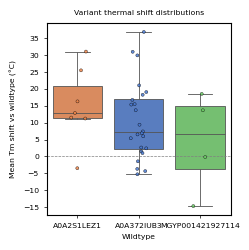

In [79]:
tm_summary_B3, variant_shift_B3 = summarize_tm_shifts(df_TM_B3)
tm_summary_B4, variant_shift_B4 = summarize_tm_shifts(df_TM_B4)

#print("Batch 3: mean Tm per enzyme")
#display(tm_summary_B3.round(3))

#print("Batch 3: variant Tm difference vs wildtype")
#display(variant_shift_B3.round(3))

#print("Batch 4: mean Tm per enzyme")
#display(tm_summary_B4.round(3))

#print("Batch 4: variant Tm difference vs wildtype")
#display(variant_shift_B4.round(3))

variant_shift_points_B3 = prepare_variant_shift_plot_df(df_TM_B3, "Batch 3")
variant_shift_points_B4 = prepare_variant_shift_plot_df(df_TM_B4, "Batch 4")
variant_shift_plot_df = pd.concat([variant_shift_points_B3, variant_shift_points_B4], ignore_index=True)

split_hues_by_batch = False
plot_size_mm = (60, 60)
plot_font_size = 5.5

plot_variant_shift_boxplot(
    variant_shift_plot_df,
    split_hues_by_batch=split_hues_by_batch,
    size_mm=plot_size_mm,
    font_size=plot_font_size
)
plt.savefig("/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Box_plot_TM_diff.pdf", bbox_inches="tight")

Best Batch 3 variants used for curve plotting


,wildtype_id,variant_name,Tm_difference_vs_wildtype,variant_mean_Tm,wildtype_mean_Tm,n_replicates
0,A0A2S1LEZ1,A0A2S1LEZ1_362,31.028,71.444,40.416,3
1,A0A372IUB3,A0A372IUB3_1847,36.835,92.292,55.457,3
2,MGYP001421927114,MGYP001421927114_1344,18.507,67.334,48.827,3


,wildtype_id,sample_type,sample_name,#Well_index,replicate_id,#Tm
0,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,F1,1,71.6617
3,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,F10,1,40.1751
1,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,F2,2,71.3416
4,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,F11,2,40.4335
2,A0A2S1LEZ1,Best variant,A0A2S1LEZ1_362,F3,3,71.3277
5,A0A2S1LEZ1,Wildtype,A0A2S1LEZ1,F12,3,40.6398
6,A0A372IUB3,Best variant,A0A372IUB3_1847,A7,1,92.4051
9,A0A372IUB3,Wildtype,A0A372IUB3,E10,1,56.8231
7,A0A372IUB3,Best variant,A0A372IUB3_1847,A8,2,92.0876
10,A0A372IUB3,Wildtype,A0A372IUB3,E11,2,55.9120


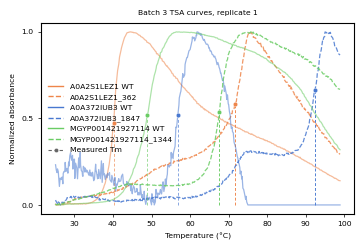

In [102]:
result_summary_B3_full = pd.read_csv(File_TM_B3)
curve_dir_B3 = os.path.dirname(File_TM_B3)

best_variant_pairs_B3, best_variant_replicates_B3, best_variant_curve_data_B3 = prepare_best_variant_curve_data(
    result_summary_B3_full,
    curve_dir_B3
)

print("Best Batch 3 variants used for curve plotting")
display(
    best_variant_pairs_B3[[
        "wildtype_id",
        "variant_name",
        "Tm_difference_vs_wildtype",
        "variant_mean_Tm",
        "wildtype_mean_Tm",
        "n_replicates"
    ]].round(3)
)

display(
    best_variant_replicates_B3[[
        "wildtype_id",
        "sample_type",
        "sample_name",
        "#Well_index",
        "replicate_id",
        "#Tm"
    ]].sort_values(["wildtype_id", "replicate_id", "sample_type"])
)

replicate_to_plot = 1
curve_plot_size_mm = (89, 60)
curve_plot_font_size = 5.5

plot_best_variant_curves(
    best_variant_curve_data_B3,
    best_variant_pairs_B3,
    replicate_to_plot=replicate_to_plot,
    size_mm=curve_plot_size_mm,
    font_size=curve_plot_font_size
)
plt.savefig("Best_variants_melting_curves.pdf", bbox_inches="tight")

# Activity resistance analysis

In [94]:
def activity_sample_sort_key(sample_name):
    sample_name = str(sample_name).strip()
    if sample_name == "NC":
        return ("zzzz", 1, sample_name)

    wildtype_id = sample_name.split("_", 1)[0]
    is_variant = "_" in sample_name

    return (wildtype_id, 1 if is_variant else 0, sample_name)


def compute_activity_rate(row, time_columns, fit_until_s=540):
    fit_time_columns = [column for column in time_columns if int(column) <= fit_until_s]
    x_values = np.array([int(column) for column in fit_time_columns], dtype=float)
    y_values = row[fit_time_columns].astype(float).to_numpy()

    if len(x_values) < 2 or np.isnan(y_values).any():
        return np.nan

    slope = np.polyfit(x_values, y_values, 1)[0]

    return -slope


def compute_minimum_signal(row, time_columns):
    signal_values = pd.to_numeric(row[time_columns], errors="coerce").to_numpy(dtype=float)

    if len(signal_values) == 0 or np.isnan(signal_values).all():
        return np.nan

    return float(np.nanmin(signal_values))


def load_activity_temperature_file(csv_path, fit_until_s=540):
    df = pd.read_csv(csv_path)
    time_columns = sorted([column for column in df.columns if str(column).isdigit()], key=int)

    df["sample_name"] = df["Sample name"].astype(str).str.strip()
    df["temperature_c"] = pd.to_numeric(df["Temperature"], errors="coerce")
    df["activity_rate"] = df.apply(
        compute_activity_rate,
        axis=1,
        time_columns=time_columns,
        fit_until_s=fit_until_s
    )
    df["minimum_signal"] = df.apply(compute_minimum_signal, axis=1, time_columns=time_columns)

    nc_rate = df.loc[df["sample_name"].eq("NC"), "activity_rate"].mean()
    if pd.isna(nc_rate):
        nc_rate = 0.0

    nc_signal_values = (
        df.loc[df["sample_name"].eq("NC"), time_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )
    if nc_signal_values.size > 0 and not np.isnan(nc_signal_values).all():
        nc_signal_reference = float(np.nanmean(nc_signal_values))
    else:
        sample_signal_values = (
            df.loc[~df["sample_name"].eq("NC"), time_columns]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
        )
        nc_signal_reference = (
            float(np.nanpercentile(sample_signal_values, 95))
            if sample_signal_values.size > 0 and not np.isnan(sample_signal_values).all()
            else np.nan
        )

    df["activity_rate_corrected"] = (df["activity_rate"] - nc_rate).clip(lower=0)
    df["nc_signal_reference"] = nc_signal_reference

    return df[[
        "Well",
        "sample_name",
        "temperature_c",
        "activity_rate",
        "activity_rate_corrected",
        "minimum_signal",
        "nc_signal_reference"
    ]].copy()


def compile_activity_resistance(activity_dir, fit_until_s=540, reference_mode="max", reference_temperature=30, catalyzed_signal_floor_quantile=0.05):
    activity_dir = os.path.abspath(activity_dir)
    csv_paths = sorted(
        glob(os.path.join(activity_dir, "Activity_assay_temperature_*.csv")),
        key=lambda path: int(os.path.splitext(path)[0].split("_")[-1])
    )

    replicate_frames = [load_activity_temperature_file(path, fit_until_s=fit_until_s) for path in csv_paths]
    activity_replicates = pd.concat(replicate_frames, ignore_index=True)
    activity_replicates = activity_replicates.loc[~activity_replicates["sample_name"].eq("NC")].copy()

    catalyzed_signal_floor = activity_replicates["minimum_signal"].quantile(catalyzed_signal_floor_quantile)
    if pd.isna(catalyzed_signal_floor):
        catalyzed_signal_floor = activity_replicates["minimum_signal"].min()

    activity_replicates["fraction_substrate_catalyzed"] = np.where(
        activity_replicates["nc_signal_reference"] > catalyzed_signal_floor,
        (activity_replicates["nc_signal_reference"] - activity_replicates["minimum_signal"])
        / (activity_replicates["nc_signal_reference"] - catalyzed_signal_floor),
        np.nan
    )
    activity_replicates["fraction_substrate_catalyzed"] = activity_replicates["fraction_substrate_catalyzed"].clip(lower=0, upper=1)

    activity_summary = (
        activity_replicates.groupby(["sample_name", "temperature_c"], as_index=False)
        .agg(
            mean_activity=("activity_rate_corrected", "mean"),
            sd_activity=("activity_rate_corrected", "std"),
            n_replicates=("activity_rate_corrected", "size"),
            mean_minimum_signal=("minimum_signal", "mean"),
            mean_nc_signal_reference=("nc_signal_reference", "mean"),
            mean_fraction_substrate_catalyzed=("fraction_substrate_catalyzed", "mean"),
            sd_fraction_substrate_catalyzed=("fraction_substrate_catalyzed", "std")
        )
    )
    activity_summary["wildtype_id"] = activity_summary["sample_name"].str.split("_", n=1).str[0]

    if reference_mode == "temperature":
        reference_activity = (
            activity_summary.loc[activity_summary["temperature_c"] == reference_temperature, ["sample_name", "mean_activity"]]
            .rename(columns={"mean_activity": "reference_activity"})
        )
    elif reference_mode == "max":
        reference_activity = (
            activity_summary.groupby("sample_name", as_index=False)["mean_activity"]
            .max()
            .rename(columns={"mean_activity": "reference_activity"})
        )
    else:
        raise ValueError("reference_mode must be 'max' or 'temperature'")

    activity_summary = activity_summary.merge(reference_activity, on="sample_name", how="left")
    activity_summary["percent_active"] = np.where(
        activity_summary["reference_activity"] > 0,
        100 * activity_summary["mean_activity"] / activity_summary["reference_activity"],
        np.nan
    )
    activity_summary["percent_active"] = activity_summary["percent_active"].clip(lower=0)
    activity_summary["percent_substrate_catalyzed"] = 100 * activity_summary["mean_fraction_substrate_catalyzed"]
    activity_summary["catalyzed_signal_floor"] = float(catalyzed_signal_floor)

    sample_order = sorted(activity_summary["sample_name"].unique(), key=activity_sample_sort_key)
    temperature_order = sorted(activity_summary["temperature_c"].dropna().astype(int).unique())
    activity_percent_pivot = (
        activity_summary.pivot(index="sample_name", columns="temperature_c", values="percent_active")
        .reindex(index=sample_order, columns=temperature_order)
    )

    return activity_replicates, activity_summary, activity_percent_pivot


def plot_activity_resistance_heatmap(activity_percent_pivot, size_mm=(110, 150), font_size=5.5, vmin=0, vmax=100):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        sns.heatmap(
            activity_percent_pivot,
            cmap="crest",
            vmin=vmin,
            vmax=vmax,
            linewidths=0.2,
            linecolor="white",
            cbar_kws={"label": "Relative activity (%)"},
            ax=ax
        )

        sample_order = list(activity_percent_pivot.index)
        wildtype_groups = [sample_name.split("_", 1)[0] for sample_name in sample_order]
        for idx in range(1, len(wildtype_groups)):
            if wildtype_groups[idx] != wildtype_groups[idx - 1]:
                ax.hlines(idx, *ax.get_xlim(), colors="black", linewidth=0.6)

        ax.set_xlabel("Temperature treatment (°C)")
        ax.set_ylabel("Sample")
        ax.set_title("Relative activity after 10 min heat treatment")
        ax.tick_params(axis="x", rotation=0, length=0)
        ax.tick_params(axis="y", length=0)
        plt.tight_layout(pad=0.4)

    return ax


def summarize_variant_retention_by_wildtype(
    activity_summary,
    retained_activity_threshold=50,
    include_wildtypes=False,
    activity_metric_column="percent_active",
    retained_flag_column="retained_activity",
    threshold_column_name="retained_activity_threshold"
):
    retention_df = activity_summary.copy()

    if not include_wildtypes:
        retention_df = retention_df.loc[
            retention_df["sample_name"] != retention_df["wildtype_id"]
        ].copy()

    retention_df = retention_df.dropna(subset=[activity_metric_column]).copy()
    retention_df[retained_flag_column] = retention_df[activity_metric_column] >= retained_activity_threshold

    retention_summary = (
        retention_df.groupby(["wildtype_id", "temperature_c"], as_index=False)
        .agg(
            n_variants_measured=("sample_name", "nunique"),
            n_variants_retained=(retained_flag_column, "sum")
        )
    )
    retention_summary["percent_variants_retained"] = np.where(
        retention_summary["n_variants_measured"] > 0,
        100 * retention_summary["n_variants_retained"] / retention_summary["n_variants_measured"],
        np.nan
    )
    retention_summary[threshold_column_name] = float(retained_activity_threshold)

    return retention_summary.sort_values(["wildtype_id", "temperature_c"]).reset_index(drop=True)


def summarize_wildtype_threshold_loss(activity_summary, retained_activity_threshold=50, minimum_temperature_c=None):
    wildtype_activity = activity_summary.loc[
        activity_summary["sample_name"] == activity_summary["wildtype_id"],
        [
            "wildtype_id",
            "temperature_c",
            "mean_activity",
            "sd_activity",
            "n_replicates",
            "percent_active"
        ]
    ].dropna(subset=["temperature_c", "percent_active"]).copy()

    if minimum_temperature_c is not None:
        wildtype_activity = wildtype_activity.loc[
            wildtype_activity["temperature_c"] >= minimum_temperature_c
        ].copy()

    summary_rows = []
    for wildtype_id, group_df in wildtype_activity.groupby("wildtype_id", sort=True):
        group_df = group_df.sort_values("temperature_c").reset_index(drop=True)
        retained_df = group_df.loc[group_df["percent_active"] >= retained_activity_threshold]
        loss_df = group_df.loc[group_df["percent_active"] < retained_activity_threshold]

        last_retained_row = retained_df.iloc[-1] if not retained_df.empty else None
        first_loss_row = loss_df.iloc[0] if not loss_df.empty else None

        summary_rows.append({
            "wildtype_id": wildtype_id,
            "last_temperature_retained_c": np.nan if last_retained_row is None else float(last_retained_row["temperature_c"]),
            "percent_active_at_last_retained": np.nan if last_retained_row is None else float(last_retained_row["percent_active"]),
            "first_temperature_below_threshold_c": np.nan if first_loss_row is None else float(first_loss_row["temperature_c"]),
            "percent_active_at_first_loss": np.nan if first_loss_row is None else float(first_loss_row["percent_active"]),
            "retained_activity_threshold": float(retained_activity_threshold),
            "evaluated_from_temperature_c": np.nan if minimum_temperature_c is None else float(minimum_temperature_c),
            "status": (
                "retained through highest tested temperature"
                if first_loss_row is None
                else "first tested temperature below threshold shown"
            )
        })

    return pd.DataFrame(summary_rows).sort_values("wildtype_id").reset_index(drop=True)


def summarize_wildtype_conversion_loss(activity_summary, substrate_conversion_threshold=50, minimum_temperature_c=None):
    wildtype_activity = activity_summary.loc[
        activity_summary["sample_name"] == activity_summary["wildtype_id"],
        [
            "wildtype_id",
            "temperature_c",
            "mean_minimum_signal",
            "mean_nc_signal_reference",
            "percent_substrate_catalyzed",
            "catalyzed_signal_floor",
            "n_replicates"
        ]
    ].dropna(subset=["temperature_c", "percent_substrate_catalyzed"]).copy()

    if minimum_temperature_c is not None:
        wildtype_activity = wildtype_activity.loc[
            wildtype_activity["temperature_c"] >= minimum_temperature_c
        ].copy()

    summary_rows = []
    for wildtype_id, group_df in wildtype_activity.groupby("wildtype_id", sort=True):
        group_df = group_df.sort_values("temperature_c").reset_index(drop=True)
        retained_df = group_df.loc[group_df["percent_substrate_catalyzed"] >= substrate_conversion_threshold]
        loss_df = group_df.loc[group_df["percent_substrate_catalyzed"] < substrate_conversion_threshold]

        last_retained_row = retained_df.iloc[-1] if not retained_df.empty else None
        first_loss_row = loss_df.iloc[0] if not loss_df.empty else None

        summary_rows.append({
            "wildtype_id": wildtype_id,
            "last_temperature_meeting_conversion_threshold_c": np.nan if last_retained_row is None else float(last_retained_row["temperature_c"]),
            "percent_substrate_catalyzed_at_last_retained": np.nan if last_retained_row is None else float(last_retained_row["percent_substrate_catalyzed"]),
            "first_temperature_below_conversion_threshold_c": np.nan if first_loss_row is None else float(first_loss_row["temperature_c"]),
            "percent_substrate_catalyzed_at_first_loss": np.nan if first_loss_row is None else float(first_loss_row["percent_substrate_catalyzed"]),
            "substrate_conversion_threshold": float(substrate_conversion_threshold),
            "evaluated_from_temperature_c": np.nan if minimum_temperature_c is None else float(minimum_temperature_c),
            "status": (
                "meets threshold through highest tested temperature"
                if first_loss_row is None
                else "first tested temperature below threshold shown"
            )
        })

    return pd.DataFrame(summary_rows).sort_values("wildtype_id").reset_index(drop=True)


def plot_variant_retention_by_wildtype(retention_summary, retained_activity_threshold=50, size_mm=(110, 70), font_size=5.5):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }
    wildtype_palette = {
        "MGYP001421927114": "#6ACC64",
        "A0A2S1LEZ1": "#EE854A",
        "A0A372IUB3": "#4878D0"
    }
    wildtype_order = sorted(retention_summary["wildtype_id"].dropna().unique())
    fallback_colors = sns.color_palette("tab10", n_colors=max(len(wildtype_order), 3)).as_hex()
    palette = {}
    fallback_idx = 0
    for wildtype_id in wildtype_order:
        if wildtype_id in wildtype_palette:
            palette[wildtype_id] = wildtype_palette[wildtype_id]
        else:
            while fallback_colors[fallback_idx] in wildtype_palette.values():
                fallback_idx += 1
            palette[wildtype_id] = fallback_colors[fallback_idx]
            fallback_idx += 1

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        sns.lineplot(
            data=retention_summary,
            x="temperature_c",
            y="percent_variants_retained",
            hue="wildtype_id",
            style="wildtype_id",
            hue_order=wildtype_order,
            markers=True,
            dashes=False,
            linewidth=1.0,
            palette=palette,
            ax=ax
        )

        ax.set_xlabel("Temperature treatment (°C)")
        ax.set_ylabel("Variants retained (%)")
        ax.set_title(f"Variants retaining at least {retained_activity_threshold}% relative activity")
        ax.set_ylim(-2, 102)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", rotation=0, length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)
        ax.legend(title="Wildtype family", frameon=False, loc="best")
        plt.tight_layout(pad=0.4)

    return ax


def plot_variant_retention_bar_by_wildtype(
    retention_summary,
    retained_activity_threshold=50,
    size_mm=(140, 70),
    font_size=5.5,
    retained_quantity_label="relative activity"
):
    rc_params = {
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "legend.title_fontsize": font_size
    }
    wildtype_order = sorted(retention_summary["wildtype_id"].dropna().unique())
    temperature_order = sorted(retention_summary["temperature_c"].dropna().astype(int).unique())
    retention_plot_df = retention_summary.copy()
    retention_plot_df = (
        retention_plot_df.set_index(["wildtype_id", "temperature_c"])
        .reindex(pd.MultiIndex.from_product([wildtype_order, temperature_order], names=["wildtype_id", "temperature_c"]))
        .reset_index()
    )
    retention_plot_df["n_variants_measured"] = retention_plot_df["n_variants_measured"].fillna(0)
    retention_plot_df["n_variants_retained"] = retention_plot_df["n_variants_retained"].fillna(0)
    retention_plot_df["percent_variants_retained"] = retention_plot_df["percent_variants_retained"].fillna(0)
    retention_plot_df["temperature_label"] = retention_plot_df["temperature_c"].astype(int).astype(str)
    temperature_label_order = [str(temp) for temp in temperature_order]
    temperature_palette = dict(
        zip(temperature_label_order, sns.color_palette("magma", n_colors=len(temperature_label_order)).as_hex())
    )

    with plt.rc_context(rc_params):
        fig, ax = plt.subplots(figsize=(mm_to_inches(size_mm[0]), mm_to_inches(size_mm[1])))
        x_positions = np.arange(len(wildtype_order), dtype=float)
        total_group_width = 0.84
        bar_width = total_group_width / max(len(temperature_order), 1)
        zero_bar_offset = 1.0

        for temperature_idx, temperature_c in enumerate(temperature_order):
            temp_label = str(temperature_c)
            temp_df = (
                retention_plot_df.loc[retention_plot_df["temperature_c"] == temperature_c]
                .set_index("wildtype_id")
                .reindex(wildtype_order)
                .reset_index()
            )
            bar_positions = (
                x_positions
                - total_group_width / 2
                + bar_width / 2
                + temperature_idx * bar_width
            )
            bar_heights = temp_df["percent_variants_retained"].to_numpy(dtype=float) + zero_bar_offset

            ax.bar(
                bar_positions,
                bar_heights,
                width=bar_width,
                bottom=-zero_bar_offset,
                color=temperature_palette[temp_label],
                edgecolor="white",
                linewidth=0.3,
                label=temp_label
            )

        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(wildtype_order)

        ax.set_xlabel("Wildtype family")
        ax.set_ylabel("Variants meeting threshold (%)")
        ax.set_title(f"Variants catalyzing at least {retained_activity_threshold}% {retained_quantity_label}")
        ax.set_ylim(-2, 102)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(axis="x", rotation=20, length=2, width=0.5)
        ax.tick_params(axis="y", length=2, width=0.5)
        ax.legend(title="Temperature (°C)", frameon=False, loc="best")
        plt.tight_layout(pad=0.4)

    return ax


temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,7.0,181.2,100.0,5.0,29.7,79.1,2.7,58.2
A0A2S1LEZ1_337,304.5,185.6,100.0,69.3,24.8,3.1,8.5,0.0
A0A2S1LEZ1_344,187.1,175.7,100.0,0.0,25.2,21.7,12.6,0.0
A0A2S1LEZ1_349,365.5,208.2,100.0,43.4,157.8,132.8,3.2,7.6
A0A2S1LEZ1_362,205.4,97.1,100.0,96.4,62.8,12.2,14.0,5.5
A0A372IUB3,31.3,33.0,100.0,180.3,135.3,28.0,11.2,11.9
A0A372IUB3_103,1.7,62.6,100.0,16.9,188.5,28.0,15.0,38.6
A0A372IUB3_104,38.0,79.1,100.0,108.0,116.4,8.3,2.2,0.0
A0A372IUB3_106,17.0,7.0,100.0,1597.3,1868.2,187.5,81.1,39.4


Wildtype temperature at which relative activity first drops below the retained activity threshold


,wildtype_id,last_temperature_retained_c,percent_active_at_last_retained,first_temperature_below_threshold_c,percent_active_at_first_loss,retained_activity_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,100.0,58.2,60.0,5.0,50.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,135.3,80.0,28.0,50.0,50.0,first tested temperature below threshold shown
2,MGYP000212420431,60.0,150.2,70.0,5.0,50.0,50.0,first tested temperature below threshold shown
3,MGYP001421927114,90.0,107.5,100.0,48.5,50.0,50.0,first tested temperature below threshold shown


Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = 12%)


temperature_c,30,40,50,60,70,80,90,100
sample_name,,,,,,,,
A0A2S1LEZ1,90.2,94.7,42.2,6.9,1.6,1.6,4.4,5.5
A0A2S1LEZ1_337,96.0,90.1,64.3,37.2,6.4,0.1,5.0,8.7
A0A2S1LEZ1_344,67.9,47.8,36.5,8.6,3.9,0.3,5.6,6.0
A0A2S1LEZ1_349,56.6,30.3,10.3,5.7,2.8,0.3,3.7,7.0
A0A2S1LEZ1_362,92.3,79.2,88.1,81.8,45.1,0.0,3.9,2.4
A0A372IUB3,89.1,93.2,94.7,48.5,34.0,0.4,1.6,1.9
A0A372IUB3_103,93.8,93.5,91.2,96.2,92.0,2.5,7.1,0.6
A0A372IUB3_104,95.1,91.0,92.5,91.2,89.6,0.4,2.6,0.0
A0A372IUB3_106,99.1,99.4,98.8,92.9,92.5,16.5,6.5,1.5


Wildtype temperature at which substrate conversion first drops below the activity requirement


,wildtype_id,last_temperature_meeting_conversion_threshold_c,percent_substrate_catalyzed_at_last_retained,first_temperature_below_conversion_threshold_c,percent_substrate_catalyzed_at_first_loss,substrate_conversion_threshold,evaluated_from_temperature_c,status
0,A0A2S1LEZ1,50.0,42.2,60.0,6.9,12.0,50.0,first tested temperature below threshold shown
1,A0A372IUB3,70.0,34.0,80.0,0.4,12.0,50.0,first tested temperature below threshold shown
2,MGYP000212420431,60.0,93.4,70.0,5.1,12.0,50.0,first tested temperature below threshold shown
3,MGYP001376212606,NaN,NaN,50.0,0.0,12.0,50.0,first tested temperature below threshold shown
4,MGYP001421927114,100.0,80.7,NaN,NaN,12.0,50.0,meets threshold through highest tested tempera...


,wildtype_id,temperature_c,n_variants_measured,n_variants_retained,percent_variants_retained,retained_activity_threshold
0,A0A2S1LEZ1,30,4,4,100.0,50.0
1,A0A2S1LEZ1,40,4,4,100.0,50.0
2,A0A2S1LEZ1,50,4,4,100.0,50.0
3,A0A2S1LEZ1,60,4,2,50.0,50.0
4,A0A2S1LEZ1,70,4,2,50.0,50.0
5,A0A2S1LEZ1,80,4,1,25.0,50.0
6,A0A2S1LEZ1,90,4,0,0.0,50.0
7,A0A2S1LEZ1,100,4,0,0.0,50.0
8,A0A372IUB3,30,20,7,35.0,50.0
9,A0A372IUB3,40,20,13,65.0,50.0


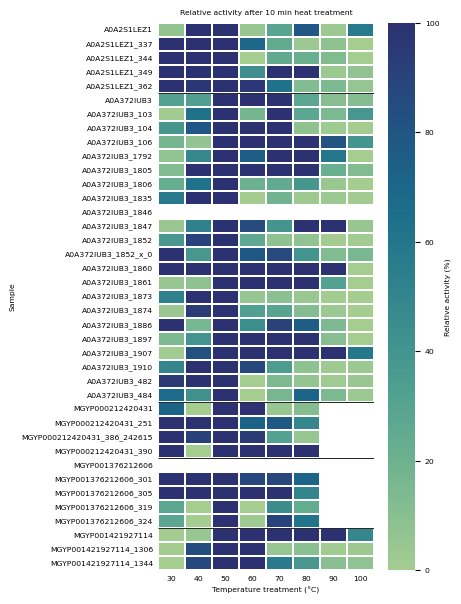

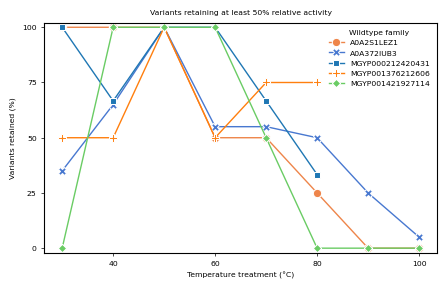

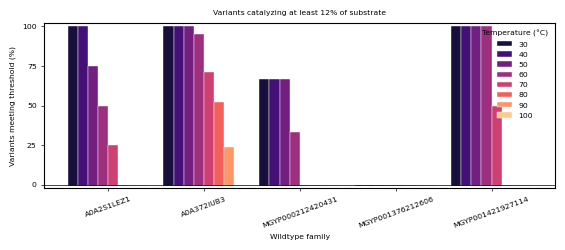

In [99]:
Activity_resistance_B3_dir = "/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Activity_Resistance/Batch_3/ThermoGAN_Batch3_Assay_20231025"

# Several sequences are more active after mild heating than at 30 C,
# so "max" is the safer default reference for percent activity.
activity_fit_until_s = 540
activity_reference_mode = "temperature" #"max"
activity_reference_temperature = 50

activity_replicates_B3, activity_summary_B3, activity_percent_active_B3 = compile_activity_resistance(
    Activity_resistance_B3_dir,
    fit_until_s=activity_fit_until_s,
    reference_mode=activity_reference_mode,
    reference_temperature=activity_reference_temperature
)

display(activity_percent_active_B3.round(1))

activity_heatmap_size_mm = (110, 150)
activity_font_size = 5.5
retained_activity_threshold = 50
substrate_conversion_threshold = 12
threshold_evaluation_min_temperature = (
    activity_reference_temperature if activity_reference_mode == "temperature" else None
)

wildtype_threshold_loss_B3 = summarize_wildtype_threshold_loss(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

wildtype_conversion_loss_B3 = summarize_wildtype_conversion_loss(
    activity_summary_B3,
    substrate_conversion_threshold=substrate_conversion_threshold,
    minimum_temperature_c=threshold_evaluation_min_temperature
)

print("Wildtype temperature at which relative activity first drops below the retained activity threshold")
display(wildtype_threshold_loss_B3.round(1))

activity_percent_substrate_catalyzed_B3 = (
    activity_summary_B3.pivot(index="sample_name", columns="temperature_c", values="percent_substrate_catalyzed")
    .reindex(index=activity_percent_active_B3.index, columns=activity_percent_active_B3.columns)
)

print(f"Percent substrate catalyzed based on the lowest observed signal in each trace (threshold = {substrate_conversion_threshold}%)")
display(activity_percent_substrate_catalyzed_B3.round(1))

print("Wildtype temperature at which substrate conversion first drops below the activity requirement")
display(wildtype_conversion_loss_B3.round(1))


plot_activity_resistance_heatmap(
    activity_percent_active_B3,
    size_mm=activity_heatmap_size_mm,
    font_size=activity_font_size
)

variant_retention_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    include_wildtypes=False
)

variant_conversion_summary_B3 = summarize_variant_retention_by_wildtype(
    activity_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    include_wildtypes=False,
    activity_metric_column="percent_substrate_catalyzed",
    retained_flag_column="retained_by_substrate_conversion",
    threshold_column_name="substrate_conversion_threshold"
)

display(variant_retention_summary_B3.round(1))

plot_variant_retention_by_wildtype(
    variant_retention_summary_B3,
    retained_activity_threshold=retained_activity_threshold,
    size_mm=(110, 70),
    font_size=activity_font_size
)

plot_variant_retention_bar_by_wildtype(
    variant_conversion_summary_B3,
    retained_activity_threshold=substrate_conversion_threshold,
    size_mm=(140, 60),
    font_size=activity_font_size,
    retained_quantity_label="of substrate"
)
plt.savefig("fraction_active_round3_2026_03_27.pdf", bbox_inches = "tight")